# ANÁLISIS DEL MERCADO GLOBAL DE VIDEOJUEGOS

## Objetivo del análisis

Este proyecto analiza datos históricos del mercado global de videojuegos con el objetivo de identificar patrones asociados al éxito comercial de los títulos. Se estudian las ventas por plataforma, género y región, así como la relación entre las calificaciones de usuarios y críticos y el desempeño comercial de los videojuegos. Finalmente, se evalúan diferencias entre mercados y se aplican pruebas estadísticas para identificar tendencias relevantes que puedan apoyar decisiones de negocio.

# 1. CARGA Y EXPLORACIÓN INICIAL DE LOS DATOS

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind
from scipy.stats import linregress
import matplotlib.pyplot as plt

In [3]:
games_df = pd.read_csv('games.csv')

In [4]:
games_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


El dataset contiene 16,715 registros. La exploración inicial muestra valores ausentes en varias variables y algunos tipos de datos que requieren conversión antes de realizar el análisis.

In [5]:
games_df.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


# 2. PREPARACIÓN DE DATOS

## Estandarización de nombres de columnas

In [6]:
#Estandarizar los nombres de las columnas

games_df.columns = games_df.columns.str.lower()

In [7]:
games_df.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

## Conversión de tipos de datos.

In [8]:
#Revisar los valores únicos de year_of_release antes de convertir su tipo de dato.

games_df['year_of_release'].unique()

array([2006., 1985., 2008., 2009., 1996., 1989., 1984., 2005., 1999.,
       2007., 2010., 2013., 2004., 1990., 1988., 2002., 2001., 2011.,
       1998., 2015., 2012., 2014., 1992., 1997., 1993., 1994., 1982.,
       2016., 2003., 1986., 2000.,   nan, 1995., 1991., 1981., 1987.,
       1980., 1983.])

La variable `year_of_release` contiene años almacenados como valores flotantes y presenta algunos registros ausentes. Se convierte a `Int64`, lo que permite representar los años como enteros conservando temporalmente los valores nulos para analizarlos posteriormente.

In [9]:
#Convertir year_of_release a un tipo entero que permita valores nulos.

games_df['year_of_release'] = games_df['year_of_release'].astype('Int64')


In [10]:
#Inspeccionar los valores de user_score antes de convertir su tipo de dato.

games_df['user_score'].unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

Podemos ver que prácticamente todos los valores son números flotantes, a excepción de "tbd" y esta columna es tipo objeto. Vamos a convertirla en tipo flotante; el contexto de la columna nos hace ver que no tiene sentido conservar su tipo original y tampoco tomar en cuenta los "tbd" porque es una calificación. Tampoco le pondremos otro valor.

In [11]:
#Convertir user_score a formato numérico; los valores no convertibles se almacenan como NaN

games_df['user_score'] = pd.to_numeric(games_df['user_score'], errors='coerce')

In [12]:
games_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.4+ MB


# Tratamiento de valores ausentes

Se calcula la proporción de valores ausentes por columna para definir una estrategia de tratamiento. En variables como critic_score, user_score y rating, una imputación arbitraria podría introducir sesgos y alterar las distribuciones originales, por lo que se conservarán los valores nulos cuando sea necesario para mantener la integridad de los datos.

In [13]:
100 * games_df.isna().sum() / len(games_df)

name                0.011965
platform            0.000000
year_of_release     1.609333
genre               0.011965
na_sales            0.000000
eu_sales            0.000000
jp_sales            0.000000
other_sales         0.000000
critic_score       51.319174
user_score         54.591684
rating             40.478612
dtype: float64

Los valores ausentes presentan proporciones muy diferentes entre variables. name y genre tienen una proporción prácticamente nula, mientras que year_of_release presenta alrededor de 1.6%. En cambio, critic_score, user_score y rating concentran una cantidad considerable de datos faltantes.

Debido a su baja incidencia, se pueden eliminar los registros sin name, genre o year_of_release con un impacto limitado sobre el tamaño del dataset. Para las variables de puntuación y clasificación, se conservarán los valores ausentes para evitar introducir información artificial.

In [14]:
#Inspeccionar los registros sin nombre
games_df[games_df['name'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


Los registros con valores ausentes en name coinciden con aquellos que también presentan valores ausentes en genre. Dado que representan una proporción mínima del dataset, estos registros pueden eliminarse sin afectar de forma significativa el análisis.

In [15]:
#Crear una copia limpia eliminando los registros sin nombre

games_clean_df = games_df.dropna(subset=['name'])

In [16]:
#Verificar los valores ausentes restantes por columna
games_clean_df.isna().sum()

name                  0
platform              0
year_of_release     269
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8576
user_score         9123
rating             6764
dtype: int64

Al eliminar los registros sin name, también se eliminaron los valores ausentes de genre, ya que ambos correspondían a los mismos registros.

In [17]:
#Eliminar los registros sin año de lanzamiento

games_clean_df = games_clean_df.dropna(subset=['year_of_release'])

In [18]:
games_clean_df.isna().sum()

name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8461
user_score         8981
rating             6676
dtype: int64

Para definir el tratamiento de los valores ausentes en user_score, critic_score y rating, se revisan sus características antes de decidir si deben eliminarse, imputarse o conservarse. Las variables de puntuación ya fueron inspeccionadas previamente, por lo que a continuación se analizan los valores presentes en rating.

In [19]:
#Inspeccionar los valores únicos de rating.

games_clean_df['rating'].unique()

array(['E', nan, 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP'], dtype=object)

La variable rating contiene categorías de clasificación ESRB y valores ausentes. Dado que no existe información suficiente para determinar la clasificación de los registros faltantes, estos valores se conservarán como NaN para evitar introducir información artificial en el dataset.

En user_score, los valores tbd indican que la puntuación aún no estaba disponible. Durante la conversión de esta variable a formato numérico, estos registros se transformaron en NaN. Tanto estos valores como los datos ausentes de critic_score y rating se conservarán sin imputación, ya que asignar valores artificiales podría distorsionar las distribuciones y afectar los análisis posteriores.

In [20]:
games_clean_df.isna().sum()

name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8461
user_score         8981
rating             6676
dtype: int64

Tras la limpieza, los valores ausentes restantes se concentran en critic_score, user_score y rating. Estos registros se conservarán para los análisis posteriores, excluyendo los valores nulos únicamente cuando sea necesario para realizar cálculos específicos.

## CÁLCULO DE VENTAS TOTALES

In [21]:
games_clean_df.loc[:, 'total_sales'] = (games_clean_df['na_sales'] + games_clean_df['eu_sales'] + games_clean_df['jp_sales'] + games_clean_df['other_sales'])

#Calcular las ventas globales de cada videojuego

In [22]:
games_clean_df.head(5)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38


# 3. ANÁLISIS EXPLORATORIO DE DATOS ##


### Juegos lanzados por año

<Axes: xlabel='year_of_release'>

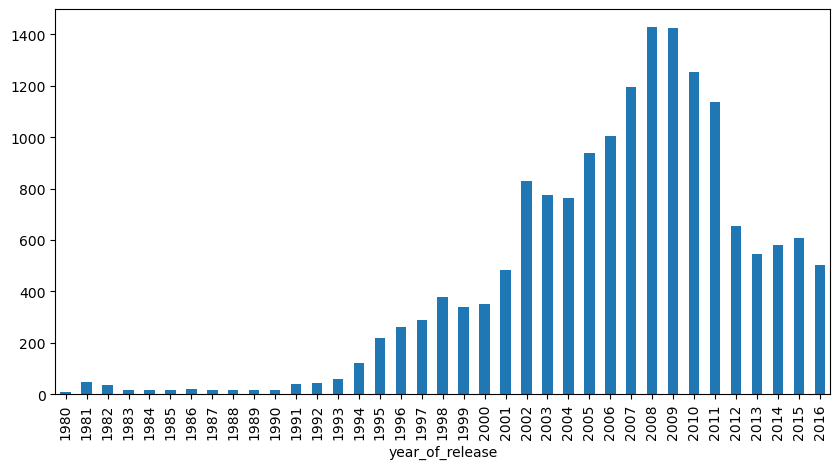

In [23]:
#Contar y visualizar el número de videojuegos lanzados por año

games_clean_df.groupby(['year_of_release'])['name'].count().plot(figsize=(10,5), kind='bar')

El número de videojuegos lanzados aumenta considerablemente a partir de la década de 1990 y alcanza sus niveles más altos durante la década de 2000, con 2008 y 2009 entre los años de mayor actividad. A partir de 2010 se observa una reducción progresiva en la cantidad de lanzamientos registrados en el dataset. Este comportamiento sugiere cambios en el ritmo de publicación de títulos a lo largo del desarrollo de la industria.

### Variación de ventas por plataforma

<Axes: xlabel='platform'>

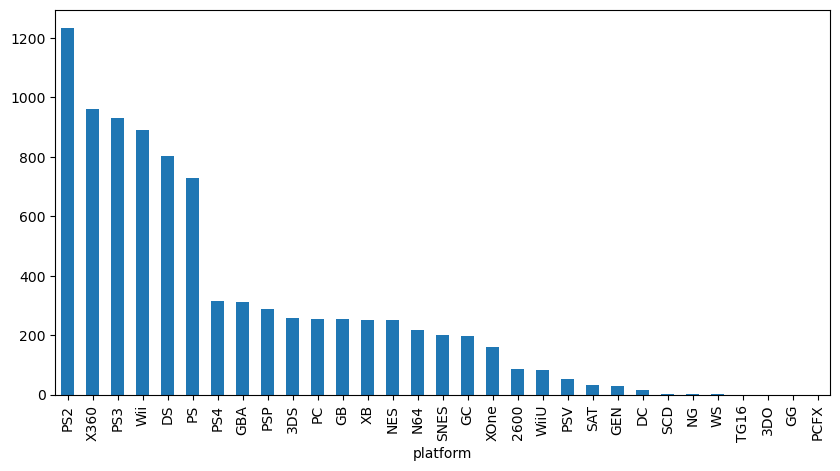

In [24]:

#Comparar las ventas globales acumuladas por plataforma

games_clean_df.groupby(['platform'])['total_sales'].sum().sort_values(ascending=False).plot(figsize=(10,5), kind='bar')


Las plataformas con mayores ventas totales son:  
- PS2
- X360
- PS3
- Wii
- DS
- PS 


In [25]:
#Seleccionar las plataformas con mayores ventas acumuladas
top_platform_sales = ['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS']
games_top_sales_df = games_clean_df[games_clean_df['platform'].isin(top_platform_sales)]

In [26]:
#Verificar las plataformas seleccionadas
games_top_sales_df['platform'].unique()

array(['Wii', 'DS', 'X360', 'PS3', 'PS2', 'PS'], dtype=object)

In [27]:
platform_df = games_top_sales_df.groupby(['platform', 'year_of_release'])['total_sales'].sum().reset_index()

In [28]:
platform_df.head()

,platform,year_of_release,total_sales
0,DS,1985,0.02
1,DS,2004,17.27
2,DS,2005,130.14
3,DS,2006,119.81
4,DS,2007,146.94


<Axes: xlabel='year_of_release', ylabel='total_sales'>

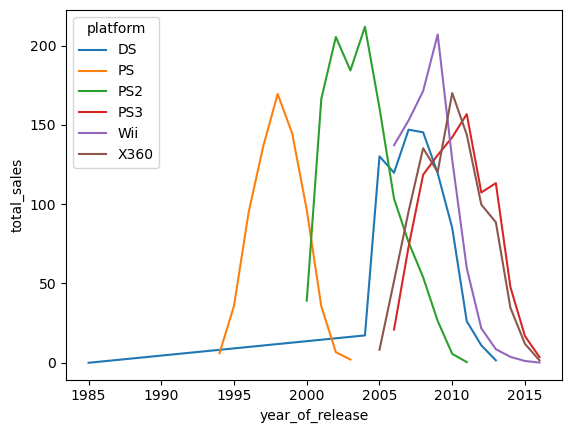

In [29]:
sns.lineplot(data = platform_df, x = 'year_of_release', y = 'total_sales', hue = 'platform')

Las plataformas líderes muestran un ciclo de crecimiento, pico y posterior descenso en sus ventas. En varios casos, la caída coincide temporalmente con la aparición de nuevas generaciones de consolas, lo que sugiere un proceso de sustitución entre plataformas a medida que avanza el mercado.

In [30]:
#Obtener el primer y último año de actividad registrado para cada plataforma

platform_years = games_clean_df.groupby('platform').agg(
    year_start = ('year_of_release', 'min'),
    year_end = ('year_of_release', 'max')
)

platform_years

,year_start,year_end
platform,,
2600,1980,1989
3DO,1994,1995
3DS,2011,2016
DC,1998,2008
DS,1985,2013
GB,1988,2001
GBA,2000,2007
GC,2001,2007
GEN,1990,1994


In [31]:
#Calcular los años transcurridos entre el primer y último lanzamiento registrado

platform_years['platform_life'] = (
    platform_years['year_end'] - platform_years['year_start']
)

platform_years

,year_start,year_end,platform_life
platform,,,
2600,1980,1989,9
3DO,1994,1995,1
3DS,2011,2016,5
DC,1998,2008,10
DS,1985,2013,28
GB,1988,2001,13
GBA,2000,2007,7
GC,2001,2007,6
GEN,1990,1994,4


In [32]:
#Calcular la duración media registrada de las plataformas

platform_years['platform_life'].mean()

np.float64(7.612903225806452)

La duración media registrada de las plataformas es de aproximadamente 8 años. Sin embargo, este resultado debe interpretarse con cautela, ya que el dataset abarca distintas generaciones de videojuegos y contiene algunos registros que pueden distorsionar la duración estimada de determinadas plataformas.

Para obtener una referencia más representativa del ciclo comercial de las plataformas relevantes para el análisis, se analizará también la duración de aquellas con mayores ventas acumuladas.

In [33]:
filtered_platforms = platform_years.loc[top_platform_sales]

filtered_platforms

,year_start,year_end,platform_life
platform,,,
PS2,2000,2011,11
X360,2005,2016,11
PS3,2006,2016,10
Wii,2006,2016,10
DS,1985,2013,28
PS,1994,2003,9


In [34]:
#Calcular la mediana de duración de las plataformas líderes en ventas
filtered_platforms['platform_life'].median()

np.float64(10.5)

La mediana de duración registrada de las plataformas líderes en ventas es de 10.5 años. Esta medida resulta más representativa que la media al reducir la influencia de valores atípicos presentes en el conjunto de datos.

### Selección el período de análisis

Para proyectar las tendencias del mercado en 2017, se utilizarán los datos correspondientes al período 2013–2016. Debido a la rápida evolución de la industria de los videojuegos, un período reciente permite reducir la influencia de plataformas y tendencias que ya no representan el contexto actual, manteniendo al mismo tiempo suficiente información histórica para identificar patrones relevantes.

In [35]:
#Seleccionar los datos correspondientes al período de análisis

final_games_df = games_clean_df[games_clean_df['year_of_release'] >= 2013]

In [36]:
final_games_df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,NaN,14.63
33,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,NaN,NaN,NaN,14.60
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62


### Plataformas líderes en ventas

Recapitulemos cuáles son las plataformas con mayores ventas acumuladas en todo el periodo disponible.

In [37]:
platform_sales = (
    games_clean_df
    .groupby('platform')['total_sales']
    .sum()
    .sort_values(ascending=False)
)

platform_sales.head(10)

platform
PS2     1233.56
X360     961.24
PS3      931.34
Wii      891.18
DS       802.78
PS       727.58
PS4      314.14
GBA      312.88
PSP      289.53
3DS      257.81
Name: total_sales, dtype: float64

En el conjunto de datos histórico, PS2, X360, PS3, Wii, DS y PS presentan las mayores ventas globales acumuladas. Sin embargo, este liderazgo histórico no implica necesariamente que continúen siendo las plataformas más relevantes para proyectar el mercado en 2017, por lo que posteriormente se analizará su desempeño durante el período reciente seleccionado.

### Evolución reciente de las ventas por plataforma

A continuación, se analizará la evolución de las ventas por plataforma durante el período 2013–2016, con el objetivo de identificar cuáles mantienen una tendencia favorable y cuáles muestran una reducción en sus ventas.

In [38]:
# Calcular las ventas anuales por plataforma durante el período de análisis

all_platform_df = (
    final_games_df.groupby(['platform', 'year_of_release'], as_index=False)
    .agg(total_sales=('total_sales', 'sum'))
)

all_platform_df

,platform,year_of_release,total_sales
0,3DS,2013,56.57
1,3DS,2014,43.76
2,3DS,2015,27.78
3,3DS,2016,15.14
4,DS,2013,1.54
5,PC,2013,12.38
6,PC,2014,13.28
7,PC,2015,8.52
8,PC,2016,5.25
9,PS3,2013,113.25


<Axes: xlabel='year_of_release', ylabel='total_sales'>

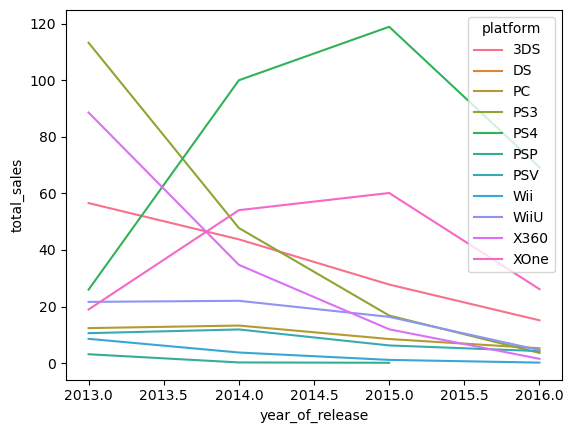

In [39]:
# Visualizar la evolución anual de las ventas por plataforma
sns.lineplot(data = all_platform_df, x = 'year_of_release', y = 'total_sales', hue = 'platform')

Durante el período 2013–2016 se observa una transición entre generaciones de consolas. PS4 y Xbox One aumentan sus ventas tras su lanzamiento y alcanzan sus niveles más altos en 2015, mientras que plataformas de la generación anterior, como PS3 y Xbox 360, muestran una disminución sostenida. Esto sugiere un desplazamiento de la demanda hacia las plataformas de nueva generación. En 2016 se observa una reducción general de las ventas, aunque este resultado debe interpretarse con cautela debido a que los datos correspondientes a ese año podrían estar incompletos.

<Axes: xlabel='year_of_release', ylabel='total_sales'>

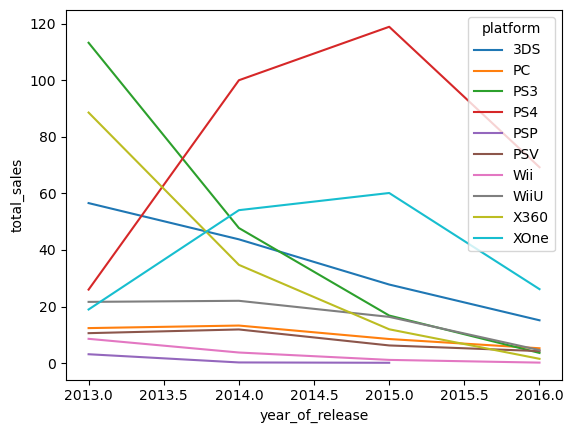

In [40]:
#Identificar las 10 plataformas con mayores ventas durante el período de análisis
top_10_platforms = (
    all_platform_df.groupby('platform')['total_sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

#Filtrar los datos de las 10 plataformas principales
df_top10 = all_platform_df[all_platform_df['platform'].isin(top_10_platforms)]

#Visualizar la evolución anual de sus ventas
sns.lineplot(
    data=df_top10,
    x='year_of_release',
    y='total_sales',
    hue='platform'
)


<Axes: xlabel='year_of_release', ylabel='total_sales'>

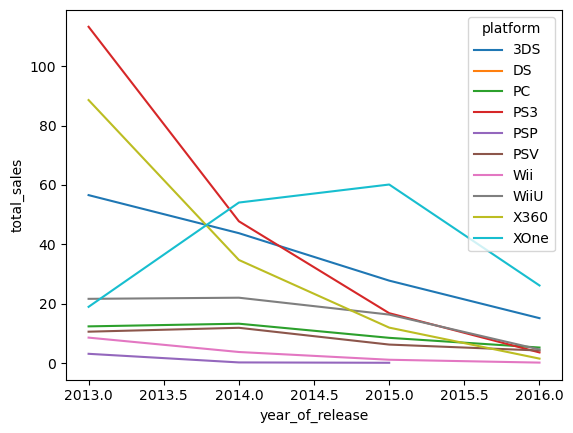

In [41]:
#Identificar las 10 plataformas con menores ventas durante el período de análisis
last_10_platforms = (
    all_platform_df.groupby('platform')['total_sales']
    .sum()
    .sort_values(ascending=True)
    .head(10)
    .index
)

#Filtrar los datos de las 10 plataformas con menores ventas
df_last10 = all_platform_df[all_platform_df['platform'].isin(last_10_platforms)]

#Visualizar la evolución anual de sus ventas
sns.lineplot(
    data=df_last10,
    x='year_of_release',
    y='total_sales',
    hue='platform'
)

In [42]:
# Analizar la evolución de las ventas durante el período 2013-2016

recent_df = all_platform_df.copy()

# Agrupar las ventas por plataforma y año
recent_sales = (
    recent_df
    .groupby(['platform', 'year_of_release'])['total_sales']
    .sum()
    .reset_index()
)

# Comparar las ventas del primer y último año disponible de cada plataforma
trend = (
    recent_sales
    .groupby('platform')
    .agg(
        first_year_sales=('total_sales', 'first'),
        last_year_sales=('total_sales', 'last')
    )
)

# Calcular el cambio neto de ventas
trend['growth'] = (
    trend['last_year_sales'] - trend['first_year_sales']
)

trend.sort_values('growth', ascending=False)


,first_year_sales,last_year_sales,growth
platform,,,
PS4,25.99,69.25,43.26
XOne,18.96,26.15,7.19
DS,1.54,1.54,0.00
PSP,3.14,0.12,-3.02
PSV,10.59,4.25,-6.34
PC,12.38,5.25,-7.13
Wii,8.59,0.18,-8.41
WiiU,21.65,4.60,-17.05
3DS,56.57,15.14,-41.43


El cambio neto permite identificar si las ventas aumentaron o disminuyeron entre el primer y el último año disponible de cada plataforma dentro del período analizado. Sin embargo, esta medida no refleja el comportamiento de las ventas durante los años intermedios, por lo que no permite determinar si la tendencia fue constante o presentó variaciones importantes.

In [43]:
#Calcular la tendencia general de ventas de cada plataforma mediante regresión lineal
def slope(df):
    return linregress(df['year_of_release'], df['total_sales']).slope

slopes = (
    recent_sales
    .groupby('platform')
    .apply(slope)
)

/var/folders/d5/v7mkv_c904z72wrz7h5f0gw80000gn/T/ipykernel_21020/738989104.py:3: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return linregress(df['year_of_release'], df['total_sales']).slope
/var/folders/d5/v7mkv_c904z72wrz7h5f0gw80000gn/T/ipykernel_21020/738989104.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(slope)


In [44]:
slopes.sort_values(ascending=False)

platform
PS4     14.868
XOne     2.764
PSP     -1.510
PSV     -2.467
PC      -2.615
Wii     -2.784
WiiU    -5.683
3DS    -14.027
X360   -28.396
PS3    -35.989
DS         NaN
dtype: float64

El análisis de las tendencias muestra diferencias claras entre las plataformas durante el período estudiado. PS4 y Xbox One presentan pendientes positivas, lo que indica una tendencia general de crecimiento en sus ventas, mientras que PS3 y Xbox 360 muestran las caídas más pronunciadas. Estos resultados reflejan una transición del mercado hacia una nueva generación de consolas y sugieren que, para analizar las perspectivas de 2017, resulta más relevante considerar la evolución reciente de las plataformas que sus ventas históricas acumuladas.

### Ventas globales

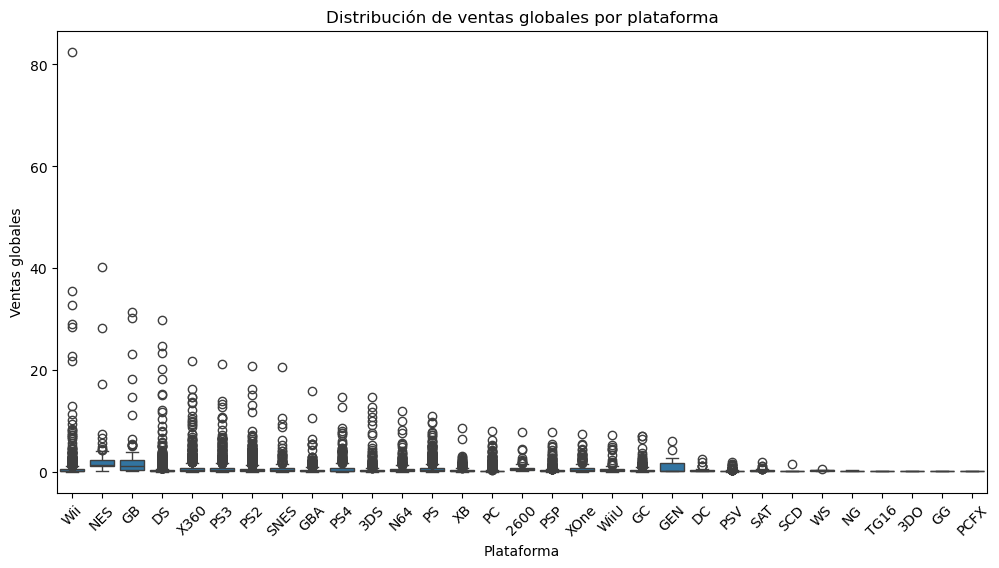

In [45]:
#Visualizar la distribución de las ventas globales por plataforma

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=games_clean_df,
    x='platform',
    y='total_sales'
)

plt.xticks(rotation=45)
plt.title('Distribución de ventas globales por plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Ventas globales')
plt.show()

El diagrama de caja muestra diferencias importantes en la distribución de las ventas globales entre plataformas. En muchas de ellas se observa una alta concentración de títulos con ventas relativamente bajas y la presencia de numerosos valores atípicos correspondientes a juegos con ventas considerablemente superiores.

La diferencia entre las medianas y la dispersión de las ventas indica que el desempeño comercial de los videojuegos varía entre plataformas. Además, algunos títulos excepcionalmente exitosos pueden alcanzar ventas muy superiores al comportamiento habitual de su plataforma.

In [46]:
#Identificar el juego de Wii con mayores ventas globales
games_clean_df[
    games_clean_df['platform'] == 'Wii'
].sort_values('total_sales', ascending=False).head(1)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54


Wii Sports es el videojuego con mayores ventas globales registrado en el dataset, con 82.54 millones de unidades, para la plataforma Wii.

In [47]:
#Calcular la media, mediana y cantidad de juegos registrados por plataforma
platform_stats = (
    games_clean_df
    .groupby('platform')['total_sales']
    .agg(['mean', 'median', 'count'])
    .sort_values('mean', ascending=False)
    )

platform_stats.head(20)

,mean,median,count
platform,,,
GB,2.622990,1.180,97
NES,2.561735,1.375,98
GEN,1.050000,0.150,27
SNES,0.836987,0.320,239
PS4,0.801378,0.200,392
X360,0.780227,0.280,1232
2600,0.745517,0.480,116
PS3,0.713124,0.280,1306
Wii,0.692986,0.190,1286


Las plataformas se muestran ordenadas de mayor a menor según la venta promedio por juego. También se incluyen la mediana y la cantidad de títulos registrados, lo que permite comparar no solo el desempeño promedio, sino también el tamaño del catálogo disponible para cada plataforma.

Algunas plataformas históricas, como GB y NES, presentan medias y medianas relativamente elevadas con un número menor de títulos registrados. En plataformas con catálogos más amplios, la diferencia entre la media y la mediana sugiere que unos pocos juegos con ventas muy altas pueden elevar considerablemente el promedio.

Por esta razón, la mediana resulta especialmente útil para comparar el desempeño típico de los juegos entre plataformas, ya que es menos sensible a títulos excepcionalmente exitosos.

In [48]:
# Comparar el desempeño de las plataformas durante el período de análisis

# Filtrar los datos correspondientes al período 2013-2016
recent_df = games_clean_df.query('year_of_release >= 2013')

# Excluir plataformas con menos de 100 juegos registrados
platform_counts = recent_df.groupby('platform').size()

valid_platforms = platform_counts[platform_counts >= 100].index

recent_df = recent_df[recent_df['platform'].isin(valid_platforms)]

# Comparar las medianas de ventas para reducir la influencia de valores atípicos
final_stats = (
    recent_df
    .groupby('platform')['total_sales']
    .agg(median_sales='median', mean_sales='mean', count='count')
    .sort_values('median_sales', ascending=False)
)

final_stats


/var/folders/d5/v7mkv_c904z72wrz7h5f0gw80000gn/T/ipykernel_21020/809862629.py:4: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  recent_df = games_clean_df.query('year_of_release >= 2013')


,median_sales,mean_sales,count
platform,,,
X360,0.265,0.735484,186
XOne,0.220,0.645020,247
PS4,0.200,0.801378,392
WiiU,0.200,0.562000,115
PS3,0.150,0.525884,345
3DS,0.090,0.472772,303
PC,0.080,0.208624,189
PSV,0.040,0.092151,358


Durante el período 2013-2016 se observan diferencias en las ventas típicas por juego entre plataformas. X360 presenta la mediana más alta, seguida de XOne, mientras que PS4 y WiiU muestran valores similares.

En todas las plataformas analizadas, la media es considerablemente superior a la mediana, lo que indica que algunos títulos con ventas especialmente altas elevan el promedio. Por esta razón, la mediana ofrece una referencia más representativa del desempeño de un juego típico en cada plataforma.

Sin embargo, estas estadísticas deben analizarse junto con la evolución temporal de las ventas. Una plataforma puede presentar buenas ventas por juego durante el período y, al mismo tiempo, encontrarse en una tendencia descendente.

### Reseñas de usuarios ###

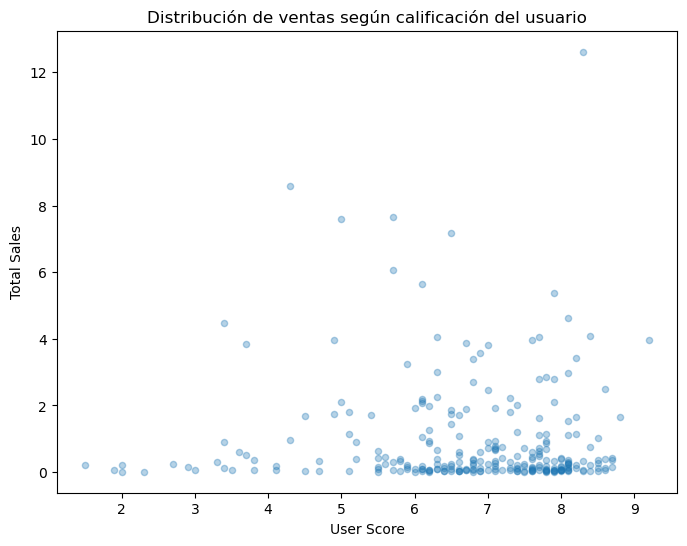

In [49]:
# Analizar la relación entre las calificaciones de los usuarios y las ventas globales
games_clean_df[games_clean_df['platform'] == 'PS4'].plot(
    title='Distribución de ventas según calificación del usuario', x='user_score', y='total_sales',
    kind='scatter', alpha=0.33, figsize=[8,6], xlabel='User Score', ylabel='Total Sales'
)

plt.show()


El diagrama de dispersión muestra que la mayoría de los juegos presenta ventas bajas independientemente de la calificación otorgada por los usuarios, con una alta concentración de puntos en la parte inferior del gráfico.

El coeficiente de correlación obtenido posteriormente (−0.032) confirma que la relación lineal entre las calificaciones de los usuarios y las ventas globales de PS4 es prácticamente nula. Por lo tanto, las puntuaciones de los usuarios no muestran una asociación clara con el nivel de ventas en los datos analizados.

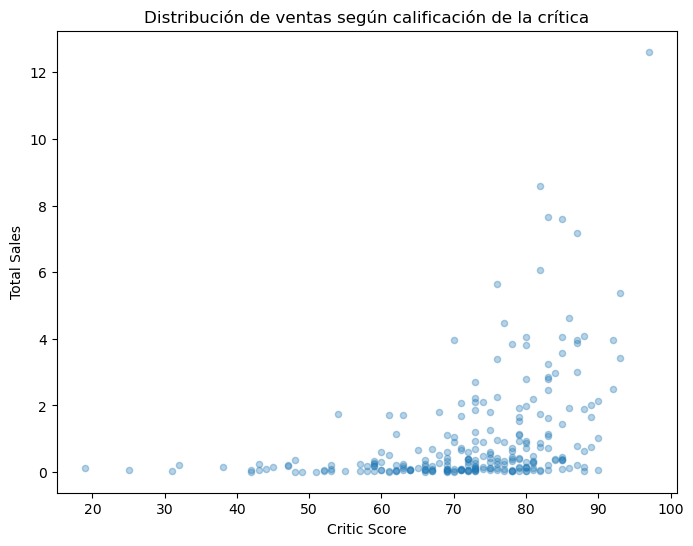

In [50]:
# Analizar la relación entre las calificaciones de los críticos y las ventas globales

games_clean_df[games_clean_df['platform'] == 'PS4'].plot(
    title='Distribución de ventas según calificación de la crítica', x='critic_score', y='total_sales',
    kind='scatter', alpha=0.33, figsize=[8,6], xlabel='Critic Score', ylabel='Total Sales'
)

plt.show()

En comparación con las calificaciones de los usuarios, el diagrama muestra visualmente una relación más definida entre las calificaciones de los críticos y las ventas globales. Sin embargo, es necesario calcular el coeficiente de correlación para cuantificar la intensidad de esta relación.

In [51]:
# Calcular la correlación entre las calificaciones y las ventas globales de PS4

ps4_scores = games_clean_df[games_clean_df['platform'] == 'PS4']

ps4_scores[['user_score', 'critic_score', 'total_sales']].corr()['total_sales']

user_score     -0.031957
critic_score    0.406568
total_sales     1.000000
Name: total_sales, dtype: float64

Al comparar ambas relaciones, se observa una diferencia clara. La correlación entre las calificaciones de los usuarios y las ventas globales de PS4 es prácticamente nula (−0.032), mientras que las calificaciones de los críticos presentan una correlación positiva moderada con las ventas (0.407).

Esto indica que, dentro de los juegos de PS4 analizados, las puntuaciones de los críticos muestran una asociación más clara con las ventas que las puntuaciones de los usuarios. Sin embargo, la correlación observada no implica causalidad y sugiere que existen otros factores que también influyen en el desempeño comercial de un videojuego.

In [52]:
# Identificar juegos multiplataforma para comparar sus ventas con PS4

# Seleccionar los juegos de PS4
ps4_games = games_clean_df[games_clean_df['platform'] == 'PS4']

# Identificar los juegos disponibles en más de una plataforma
multiplatform_games = games_clean_df.groupby('name')['platform'].nunique()
multiplatform_games = multiplatform_games[multiplatform_games > 1].index

# Filtrar el dataset para conservar únicamente los juegos multiplataforma
multi_df = games_clean_df[games_clean_df['name'].isin(multiplatform_games)]

In [53]:
# Comparar las ventas de los juegos multiplataforma entre distintas plataformas
comparison = (multi_df.groupby(['name', 'platform'])['total_sales'].sum().reset_index())

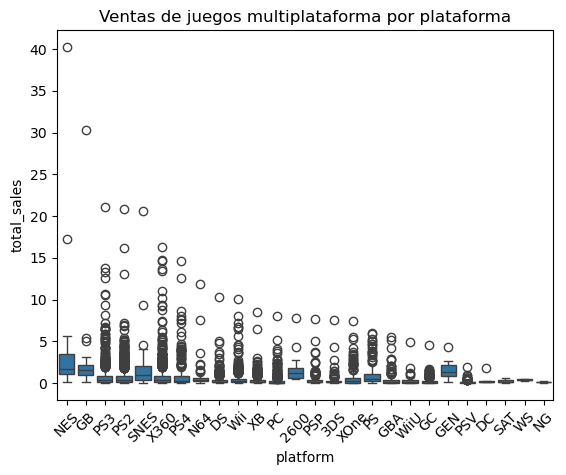

In [54]:
# Visualizar la distribución de ventas de los juegos multiplataforma por plataforma
sns.boxplot(
    data=multi_df,
    x='platform',
    y='total_sales'
)

plt.xticks(rotation=45)
plt.title('Ventas de juegos multiplataforma por plataforma')
plt.show()

El diagrama muestra diferencias en la distribución de las ventas de los juegos multiplataforma entre las distintas plataformas. La posición de las cajas permite observar que, en algunas plataformas, las ventas típicas de estos títulos son mayores que en otras.

Sin embargo, esta comparación debe interpretarse con cautela, ya que no todos los juegos multiplataforma están disponibles en las mismas plataformas.

In [55]:
# Calcular la mediana de ventas de los juegos multiplataforma por plataforma.
platform_comparison = (comparison
    .groupby('platform')['total_sales']
    .median()
    .sort_values(ascending=False)
)

platform_comparison

platform
NES     1.670
GB      1.610
GEN     1.380
2600    1.200
SNES    0.990
PS      0.520
PS2     0.390
WS      0.380
N64     0.360
PS3     0.330
X360    0.320
PS4     0.260
Wii     0.230
XOne    0.220
SAT     0.170
PSP     0.170
DS      0.160
GBA     0.155
WiiU    0.150
XB      0.150
DC      0.140
GC      0.140
3DS     0.130
PSV     0.090
NG      0.070
PC      0.060
Name: total_sales, dtype: float64

In [56]:
# Comparar las ventas de los mismos juegos entre PS4 y otras plataformas

ps4_multiplatform = comparison[
    comparison['name'].isin(ps4_games['name'])
]

game_comparison = ps4_multiplatform.pivot(
    index='name',
    columns='platform',
    values='total_sales'
)

game_comparison.head(10)

platform,2600,3DS,DS,GC,PC,PS2,PS3,PS4,PSP,PSV,Wii,WiiU,X360,XOne
name,,,,,,,,,,,,,,
7 Days to Die,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.14,NaN,NaN,NaN,NaN,NaN,0.05
Adventure Time: Finn & Jake Investigations,NaN,0.09,NaN,NaN,NaN,NaN,0.08,0.10,NaN,NaN,NaN,0.05,0.09,0.05
Aegis of Earth: Protonovus Assault,NaN,NaN,NaN,NaN,NaN,NaN,0.02,0.02,NaN,0.03,NaN,NaN,NaN,NaN
Agatha Christie's The ABC Murders,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.02,NaN,NaN,NaN,NaN,NaN,0.01
Akiba's Trip: Undead & Undressed,NaN,NaN,NaN,NaN,NaN,NaN,0.11,0.11,NaN,0.15,NaN,NaN,NaN,NaN
Alien: Isolation,NaN,NaN,NaN,NaN,0.15,NaN,0.33,1.12,NaN,NaN,NaN,NaN,0.27,0.50
Angry Birds Star Wars,NaN,0.33,NaN,NaN,NaN,NaN,0.29,0.22,NaN,0.08,0.26,0.10,0.28,0.17
Arcania: Gothic 4,NaN,NaN,NaN,NaN,0.19,NaN,NaN,0.05,NaN,NaN,NaN,NaN,0.10,NaN
Arslan: The Warriors of Legend,NaN,NaN,NaN,NaN,NaN,NaN,0.05,0.09,NaN,NaN,NaN,NaN,NaN,0.01


El análisis de los juegos multiplataforma muestra que las ventas de un mismo título pueden variar considerablemente dependiendo de la plataforma en la que se publique. La comparación juego a juego permite observar estas diferencias directamente, evitando basar la conclusión únicamente en las ventas agregadas o en la mediana de cada plataforma.

Además, las medianas muestran diferencias en las ventas típicas de los juegos multiplataforma entre plataformas. Sin embargo, estos resultados deben interpretarse con cautela, ya que no todos los títulos están disponibles en las mismas plataformas y el número de juegos registrados puede variar entre ellas.

### Distribución general de juegos por género ###

In [57]:
# Calcular la mediana de ventas globales por género para reducir la influencia de valores atípicos.
games_by_genre = (games_clean_df 
    .groupby('genre')['total_sales'] 
    .median() 
    .sort_values() 
)

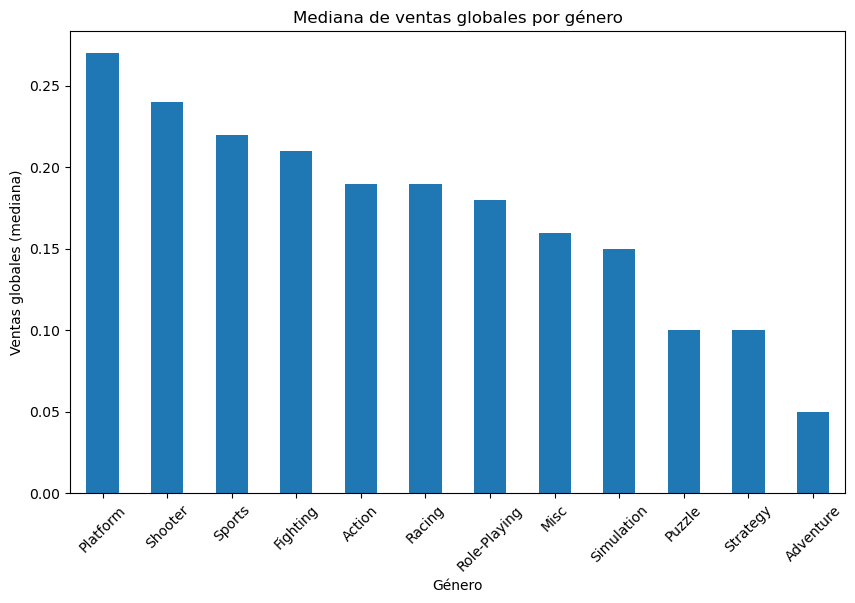

In [58]:
# Visualizar la mediana de ventas globales por género.
plt.figure(figsize=(10, 6))

games_by_genre.sort_values(ascending=False).plot(kind='bar')

plt.title('Mediana de ventas globales por género')
plt.xlabel('Género')
plt.ylabel('Ventas globales (mediana)')
plt.xticks(rotation=45)
plt.show()

In [59]:
# Comparar la mediana, la media y la cantidad de juegos registrados por género.
genre_stats = (
    games_clean_df
    .groupby('genre')['total_sales']
    .agg(
        median_sales='median',
        mean_sales='mean',
        games_count='count'
    )
    .sort_values('median_sales', ascending=False)
)

genre_stats

,median_sales,mean_sales,games_count
genre,,,
Platform,0.27,0.940262,878
Shooter,0.24,0.803519,1296
Sports,0.22,0.567940,2306
Fighting,0.21,0.528865,837
Action,0.19,0.519057,3307
Racing,0.19,0.590122,1226
Role-Playing,0.18,0.628683,1481
Misc,0.16,0.459204,1721
Simulation,0.15,0.452695,857


<Figure size 1200x600 with 0 Axes>

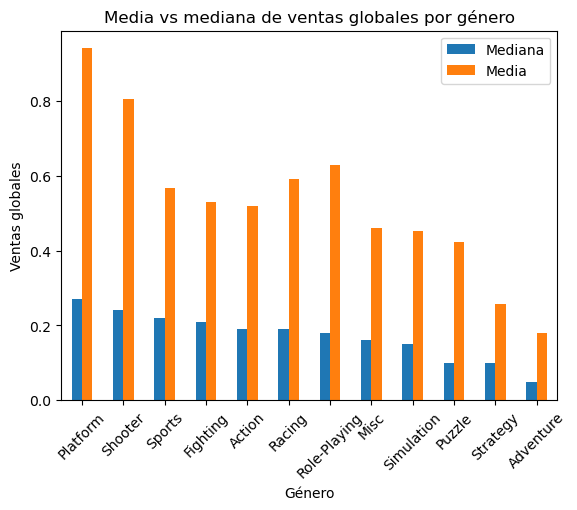

In [60]:
# Comparar la media y la mediana de ventas globales por género.

plt.figure(figsize=(12, 6))

genre_stats[['median_sales', 'mean_sales']].plot(kind='bar')

plt.title('Media vs mediana de ventas globales por género')
plt.xlabel('Género')
plt.ylabel('Ventas globales')
plt.xticks(rotation=45)
plt.legend(['Mediana', 'Media'])
plt.show()

Al comparar la media y la mediana de las ventas globales por género, se observa que la media es considerablemente superior a la mediana en todos los géneros. Esto indica que la distribución de las ventas está influida por títulos con ventas excepcionalmente altas, mientras que la mayoría de los juegos presenta cifras más moderadas.

Por esta razón, la mediana resulta especialmente útil para comparar las ventas típicas entre géneros, ya que es menos sensible a los valores atípicos. Según esta medida, Platform, Shooter, Sports, Fighting, Action y Racing se encuentran entre los géneros con mayores ventas típicas, mientras que Adventure, Strategy y Puzzle presentan las medianas más bajas.

Estos resultados permiten comparar el desempeño comercial de los géneros en términos de ventas, pero no su rentabilidad, ya que el dataset no contiene información sobre costos o beneficios.

## PASO 4. CREA UN PERFIL DE USUARIO PARA CADA REGIÓN ##

In [61]:
# Definir las regiones y sus respectivas columnas de ventas.

regions = {
    'NA': 'na_sales',
    'EU': 'eu_sales',
    'JP': 'jp_sales'
}

In [62]:
# Obtener las 5 plataformas con mayores ventas en cada región.

top_platforms_by_region = {}

for region, sales_col in regions.items():
    top_platforms_by_region[region] = (
        games_clean_df
        .groupby('platform')[sales_col]
        .sum()                          
        .sort_values(ascending=False)
        .head(5)
)

for region, data in top_platforms_by_region.items():
    print(f'\nTop 5 plataformas en {region}:')
    print(data)


Top 5 plataformas en NA:
platform
X360    595.74
PS2     572.92
Wii     486.87
PS3     390.13
DS      380.31
Name: na_sales, dtype: float64

Top 5 plataformas en EU:
platform
PS2     332.63
PS3     327.21
X360    268.32
Wii     258.32
PS      212.39
Name: eu_sales, dtype: float64

Top 5 plataformas en JP:
platform
DS      175.02
PS      139.78
PS2     137.54
SNES    116.55
3DS     100.62
Name: jp_sales, dtype: float64


Las preferencias de plataforma presentan diferencias claras entre regiones. En Norteamérica, X360 registra las mayores ventas; en Europa, PS2 ocupa el primer lugar; mientras que en Japón, DS encabeza el mercado.

También se observan diferencias en la composición de los cinco primeros lugares. Norteamérica y Europa comparten una mayor presencia de plataformas como X360, PS2, Wii y PS3, mientras que Japón muestra un perfil distinto, con plataformas como DS, PS, SNES y 3DS entre las más vendidas.

PS2 es la única plataforma que aparece entre las cinco con mayores ventas en las tres regiones, lo que refleja su amplia presencia en los distintos mercados analizados.

In [63]:
# Preparar los datos de clasificación ESRB para el análisis regional.
games_with_rating = games_clean_df.copy()
games_with_rating['rating'] = games_with_rating['rating'].fillna('Unrated')

In [64]:
# Calcular las ventas totales por clasificación ESRB y región.
rating_region_sales = (
    games_with_rating
    .groupby('rating')[['na_sales', 'eu_sales', 'jp_sales']]
    .sum()
    .sort_values('na_sales', ascending=False)
)

rating_region_sales

,na_sales,eu_sales,jp_sales
rating,,,
E,1274.24,703.87,197.96
Unrated,1225.84,609.65,836.74
T,747.60,421.79,150.70
M,742.89,480.00,63.58
E10+,345.50,183.35,40.20
K-A,2.56,0.27,1.46
EC,1.53,0.11,0.00
AO,1.26,0.61,0.00
RP,0.00,0.03,0.00


In [65]:
# Calcular la participación porcentual de cada clasificación ESRB en las ventas por región.
rating_region_share = (
    rating_region_sales
    .div(rating_region_sales.sum()) * 100
)

rating_region_share.round(2)

,na_sales,eu_sales,jp_sales
rating,,,
E,29.35,29.33,15.34
Unrated,28.24,25.41,64.83
T,17.22,17.58,11.68
M,17.11,20.00,4.93
E10+,7.96,7.64,3.11
K-A,0.06,0.01,0.11
EC,0.04,0.00,0.00
AO,0.03,0.03,0.00
RP,0.00,0.00,0.00


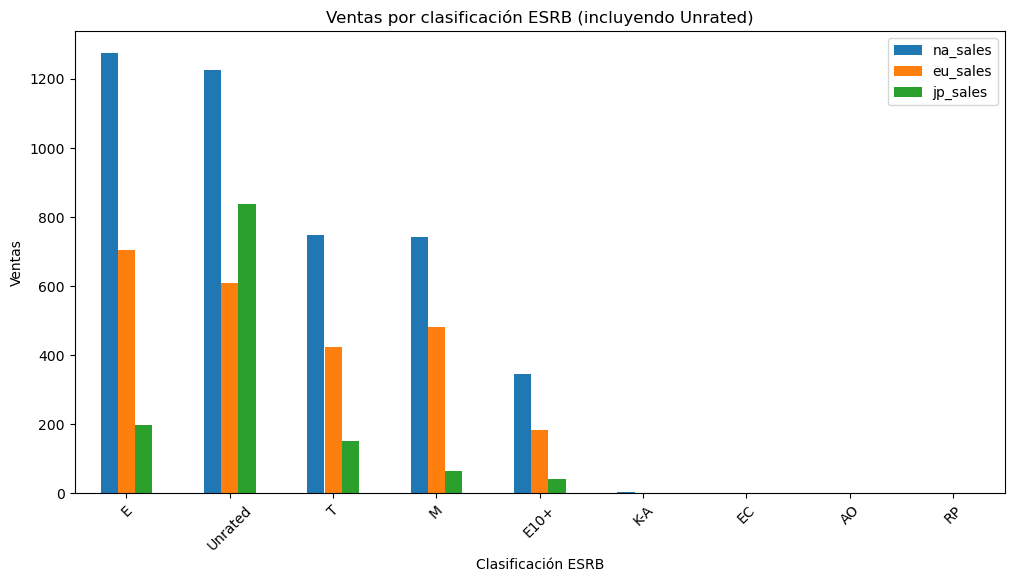

In [66]:
# Visualizar las ventas por clasificación ESRB en cada región.
rating_region_sales.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Ventas por clasificación ESRB (incluyendo Unrated)')
plt.xlabel('Clasificación ESRB')
plt.ylabel('Ventas')
plt.xticks(rotation=45)
plt.show()

La distribución de las ventas por clasificación ESRB presenta diferencias entre las regiones. En Norteamérica y Europa, los juegos clasificados como E (Everyone) concentran la mayor participación en ventas, con aproximadamente un 29% en ambas regiones.

En Japón, en cambio, destaca la categoría Unrated, que representa cerca del 65% de las ventas registradas. Esto no significa que exista una preferencia por juegos “sin clasificación”, sino que una gran proporción de los títulos del dataset no cuenta con una clasificación ESRB registrada, por lo que este resultado debe interpretarse con cautela.

Entre las principales clasificaciones ESRB, E10+ presenta una participación menor que E, T y M en las tres regiones. Las categorías K-A, EC, AO y RP registran participaciones muy reducidas en comparación con las demás.

## 5. PRUEBA DE HIPÓTESIS ##

## Hipótesis 1 ##

“Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.”

#### Hipótesis nula ####

La media de user_score en Xbox One es igual a la media de user_score en PC. 

#### Hipótesis alternativa ####

La media de user_score en Xbox One es diferente de la de PC.

Vamos a ver qué resultado nos da:

In [67]:
# Obtener las calificaciones de los usuarios para Xbox One y PC.
xone_scores = games_clean_df[
    games_clean_df['platform'] == 'XOne']['user_score'].dropna()

pc_scores = games_clean_df[
    games_clean_df['platform'] == 'PC']['user_score'].dropna()

# Realizar una prueba t de Welch para dos muestras independientes.
alpha = 0.05

t_stat, p_value = stats.ttest_ind(
    xone_scores,
    pc_scores,
    equal_var=False
)

print('t-statistic:', t_stat)
print('p-value:', p_value)

if p_value < alpha:
    print('Se rechaza la hipótesis nula')
else:
    print('No se rechaza la hipótesis nula')

t-statistic: -4.671113961085972
p-value: 4.538580296377184e-06
Se rechaza la hipótesis nula


Dado que el valor p obtenido (4.54 × 10⁻⁶) es considerablemente menor que el nivel de significancia establecido (α = 0.05), rechazamos la hipótesis nula. Por lo tanto, existe evidencia estadísticamente significativa para concluir que las calificaciones promedio de los usuarios de Xbox One y PC son diferentes.

### Hipótesis 2 ###

“Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.”

#### Hipótesis nula ####

La media de user_score para el género Acción es igual a la del género Deportes.

#### Hipótesis alternativa ####

La media de user_score para el género Acción es diferente de la del género Deportes.

In [68]:
# Obtener las calificaciones de los usuarios para los géneros Acción y Deportes

action_scores = (
    games_clean_df
    [games_clean_df['genre'] == 'Action']['user_score']
    .dropna()
)

sports_scores = (
    games_clean_df
    [games_clean_df['genre'] == 'Sports']['user_score']
    .dropna()
)

# Realizar una prueba t de Welch para dos muestras independientes

t_stat, p_value = ttest_ind(
    action_scores,
    sports_scores,
    equal_var=False
)

print(f"t-statistic: {t_stat}")
print(f"p-value: {p_value}")

alpha = 0.05

if p_value < alpha:
    print("Se rechaza la hipótesis nula")
else:
    print("No se rechaza la hipótesis nula")

t-statistic: 1.789373351094851
p-value: 0.07370217419278526
No se rechaza la hipótesis nula


Dado que el valor p obtenido (0.0737) es mayor que el nivel de significancia establecido (α = 0.05), no se rechaza la hipótesis nula. Por lo tanto, no existe evidencia estadísticamente significativa suficiente para concluir que las calificaciones promedio de los usuarios difieran entre los géneros de Acción y Deportes.

### ¿Cómo formulamos las hipótesis? ###

Para formular las hipótesis se tomó como referencia lo solicitado en el proyecto. En ambos casos, la hipótesis nula establece la igualdad entre las medias de los grupos analizados, mientras que la hipótesis alternativa plantea que existe una diferencia entre ellas.

De esta manera, las pruebas permiten evaluar si existe evidencia estadística suficiente para rechazar la igualdad de las medias.

### ¿Qué criterio usé para probar las hipótesis? ###

Se utilizó la prueba t de Welch para muestras independientes porque en ambas hipótesis se comparan las medias de dos grupos independientes y la variable analizada, user_score, es numérica.

Se utilizó equal_var=False, por lo que no se asume que las varianzas de los dos grupos sean iguales. Para ambas pruebas se estableció un nivel de significancia de α = 0.05.

El criterio de decisión fue comparar el valor p con α: si p < 0.05, se rechaza la hipótesis nula; si p ≥ 0.05, no se rechaza.

## CONCLUSIÓN GENERAL ##


En este proyecto se analizó el mercado de videojuegos con el objetivo de identificar patrones que puedan orientar la planificación de campañas para 2017. Aunque el conjunto de datos contiene información histórica de distintos periodos, para evaluar el desempeño reciente de las plataformas se consideraron especialmente los años 2013–2016, lo que permitió distinguir aquellas que mantienen actividad comercial de las que muestran una pérdida de relevancia.

En el análisis de las plataformas se observaron diferencias importantes tanto en su nivel de ventas como en su evolución reciente. Al considerar el periodo 2013–2016, PS4 y XOne se encontraron entre las plataformas con mayor actividad comercial, mientras que otras plataformas mostraron una tendencia descendente hacia el final del periodo. Además, la distribución de ventas por juego presentó valores atípicos elevados, por lo que la mediana resulta especialmente útil para representar las ventas típicas y evitar que unos pocos títulos de gran éxito distorsionen la comparación entre plataformas.

En cuanto a la relación entre las calificaciones y las ventas, las puntuaciones de los críticos presentan una correlación positiva moderada con las ventas globales (r = 0.407), mientras que las calificaciones de los usuarios muestran una correlación prácticamente nula (r = -0.032). Esto sugiere que las reseñas de los críticos pueden estar más asociadas con el desempeño comercial de un videojuego que las valoraciones de los usuarios, aunque la correlación observada no implica por sí sola una relación causal.

El género también presenta diferencias relevantes en el desempeño comercial. Al utilizar la mediana como medida de las ventas típicas, Platform registra el valor más alto con 0.27 millones de unidades por juego, seguido de Shooter con 0.24 y Sports con 0.22; en contraste, Adventure presenta una mediana de solo 0.05 millones. Además, el perfil regional muestra preferencias distintas: X360 lidera históricamente las ventas en Norteamérica con 595.74 millones de unidades, PS2 en Europa con 332.63 millones y DS en Japón con 175.02 millones. Estas diferencias muestran que tanto el género como la región deben considerarse al planificar una campaña, en lugar de aplicar una misma estrategia a todos los mercados.

El análisis de juegos multiplataforma complementa estos resultados al mostrar que un mismo título puede alcanzar niveles de ventas diferentes dependiendo de la plataforma en la que se publica. La comparación juego a juego permite separar mejor el efecto de la plataforma del efecto del propio título, reforzando la idea de que la elección de plataforma es un factor relevante al evaluar el potencial comercial de un videojuego.

Finalmente, las pruebas de hipótesis aportaron evidencia estadística sobre las diferencias entre determinados segmentos. Para Xbox One y PC se obtuvo un valor p de 4.54 × 10⁻⁶, inferior a α = 0.05, por lo que se rechazó la hipótesis nula de igualdad entre las calificaciones promedio de los usuarios. En cambio, al comparar los géneros de Acción y Deportes se obtuvo un valor p de 0.0737, por lo que no se rechazó la hipótesis nula. En conjunto, los resultados muestran que la planificación para 2017 debería considerar de forma diferenciada la evolución reciente de las plataformas, el género de los videojuegos y las particularidades de cada región, en lugar de basarse únicamente en el desempeño histórico del mercado.